# Artifacts Inspection

Notebook to inspect the derivatives and results of the NEMESIS project pipeline.

## Matrices

### `21-07_run1`

Path: `/home/etosato/Projects/NEMESIS_fs/data/derived/lesion_matrix/21-07_run1`

#### Loading

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

deriv_dir = "/home/etosato/Projects/NEMESIS_fs/data/derived/lesion_matrix/21-07_run1"

In [2]:
# Load Manifest
manifest_path = os.path.join(deriv_dir, "manifest.json")
with open(manifest_path, "r") as f:
    manifest = json.load(f)

print("Manifest:")
print(json.dumps(manifest, indent=2))

Manifest:
{
  "created_at": "2026-07-21T09:16:34.539193+00:00",
  "matrix_shape": [
    1150,
    254865
  ],
  "matrix_dtype": "uint8",
  "metadata_columns": [
    "subject_id",
    "dataset"
  ],
  "extra_arrays": {
    "non_constant_mask": [
      902629
    ]
  }
}


In [3]:
# Load Metadata
metadata_path = os.path.join(deriv_dir, "metadata.csv")
df_meta = pd.read_csv(metadata_path)

print(f"\nMetadata shape: {df_meta.shape}")
display(df_meta.head())


Metadata shape: (1150, 2)


,subject_id,dataset
0,sub-STUNIPD0001,UNIPD/WashU
1,sub-STUNIPD0002,UNIPD/WashU
2,sub-STUNIPD0003,UNIPD/WashU
3,sub-STUNIPD0005,UNIPD/WashU
4,sub-STUNIPD0006,UNIPD/WashU


In [4]:
# Load Matrix
matrix_path = os.path.join(deriv_dir, "matrix.npy")
matrix = np.load(matrix_path)

print(f"Matrix shape: {matrix.shape}")
print(f"Matrix dtype: {matrix.dtype}")
print(f"Sparsity (fraction of non-zeros): {np.count_nonzero(matrix) / matrix.size:.4f}")

Matrix shape: (1150, 254865)
Matrix dtype: uint8
Sparsity (fraction of non-zeros): 0.0174


In [5]:
# Load Non-constant Mask
mask_path = os.path.join(deriv_dir, "non_constant_mask.npy")
if os.path.exists(mask_path):
    mask = np.load(mask_path)
    print(f"Non-constant mask shape: {mask.shape}")
    print(f"Non-constant mask sum: {mask.sum()}")
else:
    print("Non-constant mask not found.")

Non-constant mask shape: (902629,)
Non-constant mask sum: 254865


#### Basic Exploration

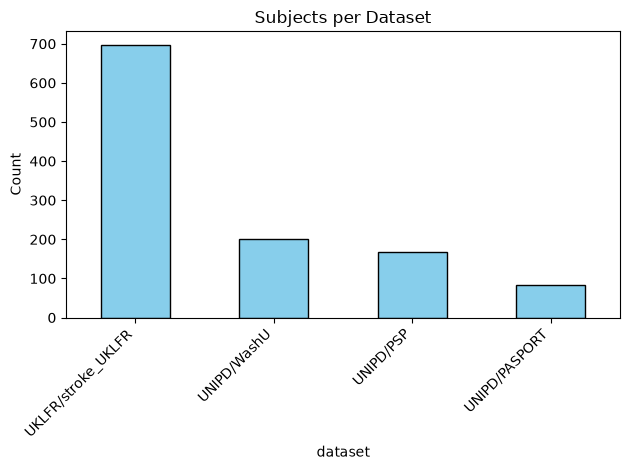

In [6]:
# Dataset distribution
if 'dataset' in df_meta.columns:
    df_meta['dataset'].value_counts().plot(kind='bar', title='Subjects per Dataset', color='skyblue', edgecolor='black')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Dataset column not found in metadata")

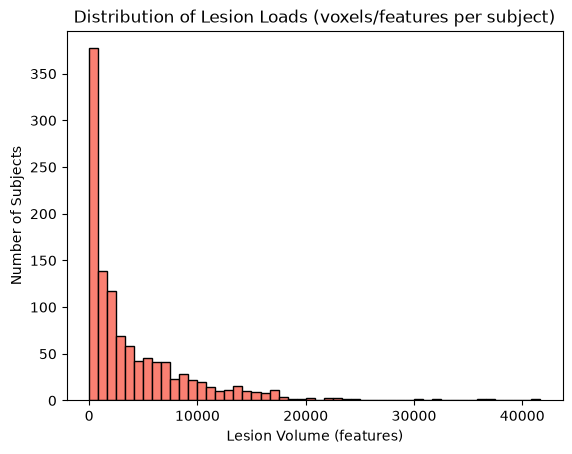

In [7]:
# Lesion load distribution (sum of lesion voxels per subject)
lesion_loads = matrix.sum(axis=1)
plt.hist(lesion_loads, bins=50, edgecolor='black', color='salmon')
plt.title('Distribution of Lesion Loads (voxels/features per subject)')
plt.xlabel('Lesion Volume (features)')
plt.ylabel('Number of Subjects')
plt.show()